<h1>Capítulo 3 - Olhando por Dentro dos LLMs Baseados em Transformer</h1>
<i>Um estudo aprofundado da arquitetura Transformer usada em LLMs generativos</i>

---

**Material de apoio da disciplina Tópicos Especiais em Inteligência Artificial (IFPE, Campus Paulista)**

Este notebook é uma adaptação, tradução e ampliação do notebook original do Capítulo 3 do livro [Hands-On Large Language Models](https://www.amazon.com/Hands-Large-Language-Models-Understanding/dp/1098150961), de [Jay Alammar](https://www.linkedin.com/in/jalammar) e [Maarten Grootendorst](https://www.linkedin.com/in/mgrootendorst/). O código-fonte original foi mantido sem alterações; os comentários em markdown foram traduzidos para o português, expandidos com explicações adicionais e conectados diretamente ao conteúdo teórico do Capítulo 3 do livro.

---

<a href="https://www.amazon.com/Hands-Large-Language-Models-Understanding/dp/1098150961">
<img src="https://raw.githubusercontent.com/HandsOnLLM/Hands-On-Large-Language-Models/main/images/book_cover.png" width="350"/></a>

## Objetivo desta aula

Nas aulas anteriores da disciplina trabalhamos com embeddings (Word2Vec, TF-IDF) e com tokenizadores. Agora vamos abrir o "capô" de um LLM real e observar, passo a passo, o que acontece entre a entrada de um texto e a geração do próximo token: como o modelo é estruturado internamente (tokenizador, blocos Transformer, cabeça de modelagem de linguagem), como a atenção permite que cada token "olhe" para os tokens anteriores, como o modelo escolhe qual token gerar a partir de uma distribuição de probabilidades, e por que o cache de chaves e valores (KV cache) é essencial para a geração de texto em tempo real.

## Por que este notebook não usa API (Gemini, OpenRouter, Hugging Face Inference)

Em praticamente todas as outras aulas da disciplina usamos APIs gratuitas de LLM (Gemini via Google AI Studio, OpenRouter, etc.), pois isso evita a necessidade de GPU e de infraestrutura local. Esta aula é uma exceção proposital: para "olhar por dentro" do modelo (inspecionar camadas, ativações, pesos de atenção e a saída bruta da cabeça de modelagem de linguagem antes da decodificação) precisamos ter o modelo carregado localmente, com acesso direto aos seus pesos internos via biblioteca `transformers`. Isso é simplesmente impossível através de uma API de chat: a API devolve apenas o texto final gerado, nunca os tensores internos do modelo.

**Onde executar:**
- **Google Colab (recomendado):** ative uma GPU gratuita em `Runtime > Change runtime type > Hardware accelerator > GPU > GPU type > T4` antes de rodar as células abaixo. O modelo usado (Phi-3-mini, 3,8 bilhões de parâmetros) roda confortavelmente em uma T4 (16 GB de VRAM).
- **Instâncias EC2 sem GPU:** se sua instância não tiver GPU, o carregamento do Phi-3-mini em CPU será lento e consumirá bastante RAM (o modelo ocupa cerca de 7-8 GB em `float16`/`bfloat16` e ainda mais em `float32`). Para fins didáticos, uma alternativa é substituir o modelo por um consideravelmente menor, como `Qwen/Qwen2.5-0.5B-Instruct` ou `HuggingFaceTB/SmolLM2-360M-Instruct`, trocando apenas o nome do modelo na célula de carregamento. Os conceitos discutidos (tokenizador, blocos Transformer, cabeça LM, cache de KV) são idênticos, apenas a escala do modelo muda.


### [OPCIONAL] - Instalando pacotes

Se você está executando este notebook no Google Colab (ou em qualquer outro provedor de nuvem), **descomente e execute** o bloco de código abaixo para instalar as dependências deste capítulo.

---

**NOTA:** vamos usar uma GPU para rodar os exemplos deste notebook. No Google Colab, vá em
**Runtime > Change runtime type > Hardware accelerator > GPU > GPU type > T4**.

Se estiver rodando em uma máquina própria (por exemplo, uma instância EC2), instale as mesmas versões indicadas abaixo em um ambiente virtual dedicado, e verifique se há GPU disponível com `torch.cuda.is_available()`. Sem GPU, use um modelo menor conforme sugerido na célula anterior.

---


In [ ]:
# %%capture
# !pip install transformers>=4.41.2 accelerate>=0.31.0

# Carregando o LLM

Vamos carregar o modelo **Phi-3-mini-4k-instruct**, da Microsoft (3,8 bilhões de parâmetros, contexto de 4 mil tokens, ajustado por instrução). É um modelo pequeno o suficiente para caber em uma GPU gratuita do Colab, mas grande o bastante para produzir respostas coerentes e ilustrar bem a arquitetura Transformer.

A célula abaixo usa três classes centrais da biblioteca `transformers` (Hugging Face):

- **`AutoTokenizer`**: carrega o tokenizador treinado junto com o modelo. Como vimos no Capítulo 2, o tokenizador mantém o vocabulário do modelo e converte texto em uma sequência de IDs de token (e vice-versa na saída).
- **`AutoModelForCausalLM`**: carrega os pesos do modelo propriamente dito, já configurado para a tarefa de modelagem de linguagem causal (ou seja, prever o próximo token dado os anteriores). O parâmetro `device_map="cuda"` envia o modelo para a GPU, e `torch_dtype="auto"` deixa a biblioteca escolher a precisão numérica mais eficiente disponível (tipicamente `bfloat16` ou `float16`).
- **`pipeline`**: uma interface de alto nível que encapsula tokenização, forward pass, decodificação e destokenização em uma única chamada, retornando diretamente o texto gerado.

Segundo o livro, um LLM Transformer é composto por três partes principais: o tokenizador, uma pilha de blocos Transformer e uma cabeça de modelagem de linguagem (LM head). É exatamente essa estrutura que vamos observar na sequência deste notebook.

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline

# Load model and tokenizer
tokenizer = AutoTokenizer.from_pretrained("microsoft/Phi-3-mini-4k-instruct")

model = AutoModelForCausalLM.from_pretrained(
    "microsoft/Phi-3-mini-4k-instruct",
    device_map="cuda",
    torch_dtype="auto",
    trust_remote_code=False,
)

# Create a pipeline
generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    return_full_text=False,
    max_new_tokens=50,
    do_sample=False,
)

config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.44k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.94M [00:00<?, ?B/s]

tokenizer.model: reconstructing file:   0%|          |  0.00B /  500kB            

tokenizer.model: downloading bytes:           |  0.00B            

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


# Entradas e saídas de um Transformer LLM treinado

Um LLM gera texto **um token de cada vez**. Após gerar um token, ele é concatenado ao prompt original, e essa sequência atualizada é apresentada novamente ao modelo para gerar o próximo token. Esse processo se repete em loop até atingir um critério de parada (token de fim de sequência ou o limite `max_new_tokens`).

Internamente, cada passagem por esse loop (chamada de *forward pass*) segue o fluxo: **tokenizador -> pilha de blocos Transformer -> cabeça de modelagem de linguagem (LM head)**. A LM head é a camada final da rede, responsável por transformar a representação interna do último token em uma pontuação de probabilidade para cada token do vocabulário (ou seja, "qual é o próximo token mais provável?"). A escolha de qual token efetivamente será usado cabe à estratégia de decodificação, que discutiremos mais adiante neste notebook.

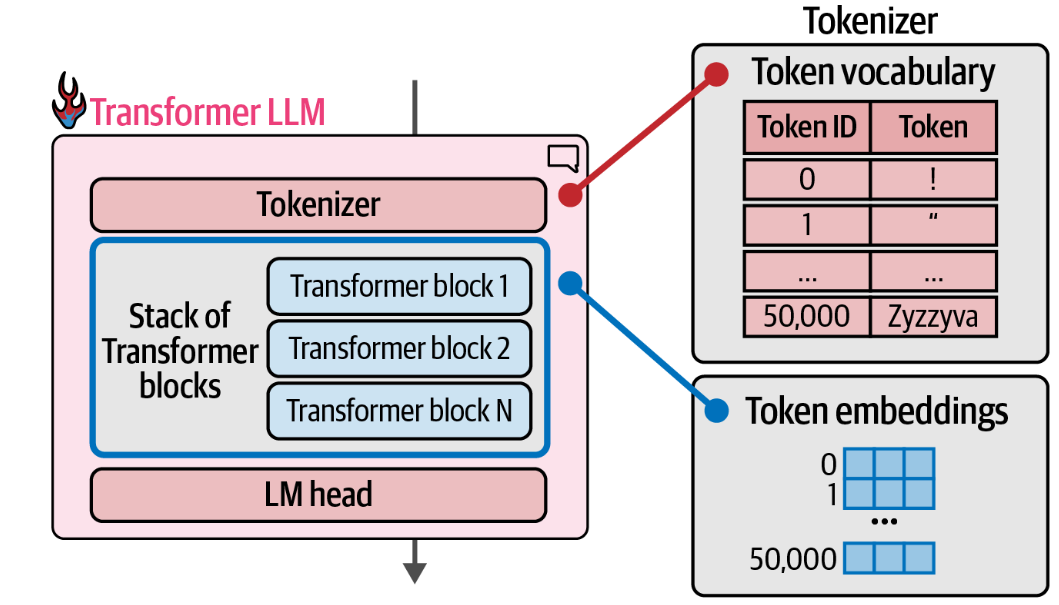

Na célula abaixo, note que a geração para de forma abrupta: isso acontece porque limitamos `max_new_tokens=50` na configuração do `pipeline`. Se aumentarmos esse limite, o modelo continuaria escrevendo até concluir o e-mail (ou até atingir o próprio critério natural de parada).

In [ ]:
prompt = "Write an email apologizing to Sarah for the tragic gardening mishap. Explain how it happened."

output = generator(prompt)

print(output[0]['generated_text'])

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[transformers] Both `max_new_tokens` (=50) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Mention the steps you're taking to prevent it in the future.

Dear Sarah,

I hope this message finds you well. I am writing to express my sincerest apologies for the unfortunate incident that occurred


## Inspecionando a arquitetura do modelo

Ao imprimir o objeto `model`, o PyTorch exibe a árvore completa de camadas que compõem o Phi-3-mini. Vale a pena parar aqui e conectar cada peça ao que discutimos em teoria:

- **`embed_tokens`** (`Embedding(32064, 3072)`): a tabela de embeddings de token. O vocabulário do tokenizador tem 32.064 tokens, e cada um deles possui um vetor de 3.072 dimensões associado (a chamada "dimensão do modelo"). É exatamente a mesma ideia de tabela de vocabulário + embeddings que vimos na aula sobre Tokenização, só que em escala de produção.
- **`layers` (0-31): 32 x `Phi3DecoderLayer`**: a pilha de blocos Transformer. O Phi-3-mini possui 32 blocos empilhados; cada bloco processa a saída do bloco anterior e repassa adiante. Modelos maiores podem ter mais de cem blocos.
- **Dentro de cada bloco, `self_attn` (camada de atenção)**: `qkv_proj` projeta a entrada nas matrizes de consultas (query), chaves (key) e valores (value) de uma só vez (uma otimização comum de implementação); `o_proj` combina novamente a saída das cabeças de atenção; `rotary_emb` implementa **RoPE (Rotary Positional Embeddings)**, o esquema de codificação posicional que informa ao modelo a ordem dos tokens na sequência.
- **`mlp` (a rede feedforward)**: `gate_up_proj` e `down_proj`, com ativação `SiLU`, formam a variante **SwiGLU** da rede feedforward, hoje mais comum do que a ativação ReLU usada no Transformer original. É essa rede feedforward, presente em cada bloco, que concentra a maior parte da capacidade de memorização e interpolação do modelo.
- **`input_layernorm` e `post_attention_layernorm` (`Phi3RMSNorm`)**: normalização aplicada **antes** da atenção e da rede feedforward (pré-normalização), usando **RMSNorm**, uma variante mais simples e eficiente do que o LayerNorm original.
- **`lm_head`** (`Linear(3072, 32064)`): a cabeça de modelagem de linguagem, que projeta o vetor de saída de 3.072 dimensões de volta para o espaço do vocabulário de 32.064 tokens, gerando a pontuação de cada token candidato.

Essa é a arquitetura de um Transformer "decoder-only" típica de 2024, com as otimizações que o livro chama de "Recent Improvements to the Transformer Architecture": pré-normalização com RMSNorm, ativação SwiGLU e embeddings posicionais rotativas (RoPE).

In [ ]:
print(model)

Phi3ForCausalLM(
  (model): Phi3Model(
    (embed_tokens): Embedding(32064, 3072, padding_idx=32000)
    (layers): ModuleList(
      (0-31): 32 x Phi3DecoderLayer(
        (self_attn): Phi3Attention(
          (o_proj): Linear(in_features=3072, out_features=3072, bias=False)
          (qkv_proj): Linear(in_features=3072, out_features=9216, bias=False)
        )
        (mlp): Phi3MLP(
          (gate_up_proj): Linear(in_features=3072, out_features=16384, bias=False)
          (down_proj): Linear(in_features=8192, out_features=3072, bias=False)
          (activation_fn): SiLUActivation()
        )
        (input_layernorm): Phi3RMSNorm((3072,), eps=1e-05)
        (post_attention_layernorm): Phi3RMSNorm((3072,), eps=1e-05)
        (resid_attn_dropout): Dropout(p=0.0, inplace=False)
        (resid_mlp_dropout): Dropout(p=0.0, inplace=False)
      )
    )
    (norm): Phi3RMSNorm((3072,), eps=1e-05)
    (rotary_emb): Phi3RotaryEmbedding()
  )
  (lm_head): Linear(in_features=3072, out_featur

# Escolhendo um único token a partir da distribuição de probabilidades (amostragem / decodificação)

Ao final do forward pass, a saída do modelo é uma pontuação de probabilidade para **cada token do vocabulário** (nesse caso, 32.064 valores). O método usado para transformar essa distribuição de probabilidades em um único token de saída é chamado de **estratégia de decodificação**.

Duas estratégias principais:

- **Decodificação gulosa (*greedy decoding*)**: sempre escolhe o token com a maior probabilidade. É o que acontece quando o parâmetro de temperatura é ajustado para zero. Na prática, essa estratégia tende a gerar textos mais repetitivos e menos naturais.
- **Amostragem (*sampling*)**: em vez de escolher sempre o token mais provável, sorteia-se um token de acordo com a própria distribuição de probabilidades. Assim, um token com 40% de probabilidade tem 40% de chance de ser escolhido, mas outros tokens também podem ser sorteados. Esse comportamento é controlado, entre outros, pelo parâmetro de temperatura (tema que será aprofundado em uma aula futura sobre geração de texto e prompting).

No exemplo abaixo, fazemos manualmente o que o `pipeline` faz internamente: tokenizamos o prompt, passamos pelo modelo (sem passar pela `lm_head` ainda), depois aplicamos a `lm_head` separadamente para obter a distribuição de probabilidades do próximo token. Ao aplicar `argmax(-1)` sobre essa distribuição, estamos fazendo decodificação gulosa manualmente: escolhendo o token de maior pontuação.

**Fonte:** ALAMMAR; GROOTENDORST, 2024, cap. 3, seção "Choosing a Single Token from the Probability Distribution (Sampling/Decoding)", p. 79-81.

In [ ]:
prompt = "The capital of France is"

# Tokenize the input prompt
input_ids = tokenizer(prompt, return_tensors="pt").input_ids

# Tokenize the input prompt
input_ids = input_ids.to("cuda")

# Get the output of the model before the lm_head
model_output = model.model(input_ids)

# Get the output of the lm_head
lm_head_output = model.lm_head(model_output[0])

In [ ]:
lm_head_output[0, -1]

tensor([27.8750, 29.5000, 28.0000,  ..., 20.3750, 20.3750, 20.3750],
       device='cuda:0', dtype=torch.bfloat16, grad_fn=<SelectBackward0>)

In [ ]:
token_id = lm_head_output[0,-1].argmax(-1)
tokenizer.decode(token_id)

'Paris'

## Extensão: visualizando os pesos de atenção (prática adicional)

A atenção (self-attention) funciona em duas etapas, para cada posição (token) sendo processada:

1. **Pontuação de relevância**: o vetor de consulta (*query*) da posição atual é multiplicado pela matriz de chaves (*keys*) de todas as posições anteriores, gerando uma pontuação de quão relevante cada token anterior é para o token atual. Uma função softmax normaliza essas pontuações para que somem 1.
2. **Combinação da informação**: cada vetor de valor (*value*) é multiplicado pela pontuação de relevância correspondente, e a soma desses vetores produz a saída daquela etapa de atenção.

Formalmente, para uma única cabeça de atenção:

$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^{T}}{\sqrt{d_k}}\right)V
$$

em que $Q$, $K$ e $V$ são as matrizes de consultas, chaves e valores, e $d_k$ é a dimensão dos vetores de chave (usada para estabilizar a escala dos produtos internos). Essa formulação vem do artigo original do Transformer, "Attention Is All You Need" (VASWANI et al., 2017).

Como vimos na impressão da arquitetura, o módulo `self_attn` de cada bloco realiza essa operação em paralelo em múltiplas cabeças de atenção (*multi-head attention*), permitindo que o modelo capture diferentes tipos de relação entre os tokens simultaneamente.

A célula abaixo extrai os pesos de atenção da primeira camada e da primeira cabeça do Phi-3-mini para um prompt curto, e os exibe como um mapa de calor. Cada linha representa um token "consultando" (query); cada coluna, um token "consultado" (key). Repare que a matriz é triangular: como o Phi-3 é um modelo decoder autorregressivo (assim como a maioria dos modelos de geração de texto), cada token só pode atender a si mesmo e aos tokens anteriores, nunca aos posteriores (diferente do BERT, que é bidirecional).

[transformers] The following generation flags are not valid and may be ignored: ['output_attentions']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

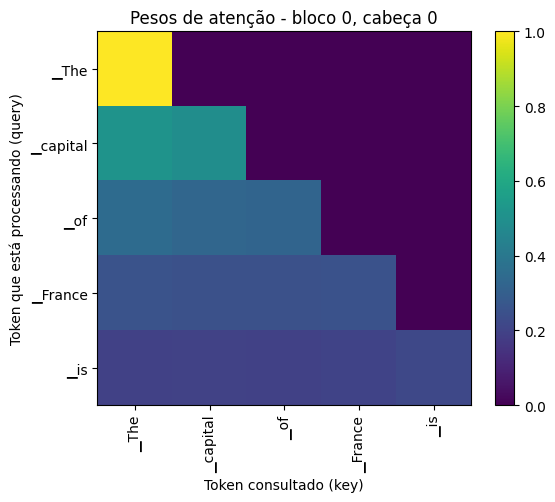

In [ ]:
import torch
import matplotlib.pyplot as plt
from transformers import AutoConfig, AutoModelForCausalLM, AutoTokenizer # Added AutoConfig

# Re-load tokenizer and model with attention output enabled.
# This is done here to ensure `saida.attentions` is populated
# as per the strict constraint to modify ONLY this cell.
# In a real scenario, it would be better to modify the initial model loading cell (e.g., 517905f0).
config = AutoConfig.from_pretrained("microsoft/Phi-3-mini-4k-instruct")
config.output_attentions = True

tokenizer = AutoTokenizer.from_pretrained("microsoft/Phi-3-mini-4k-instruct")
model = AutoModelForCausalLM.from_pretrained(
    "microsoft/Phi-3-mini-4k-instruct",
    config=config, # Pass the modified config
    device_map="cuda",
    torch_dtype="auto",
    trust_remote_code=False,
)

prompt_ilustrativo = "The capital of France is"
entrada = tokenizer(prompt_ilustrativo, return_tensors="pt").to(model.device)

with torch.no_grad():
    saida = model(**entrada, output_attentions=True)

# saida.attentions é uma tupla com um tensor por bloco Transformer
# formato de cada tensor: [batch, numero_de_cabecas, seq_len, seq_len]
camada = 0  # primeiro bloco Transformer
cabeca = 0  # primeira cabeça de atenção

# Check if attentions are actually returned before attempting to access them
if not saida.attentions:
    print("Error: Model did not return attention weights despite output_attentions=True. Cannot plot.")
else:
    pesos_atencao = saida.attentions[camada][0, cabeca].float().cpu().numpy()
    tokens = tokenizer.convert_ids_to_tokens(entrada["input_ids"][0])

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(pesos_atencao, cmap="viridis")
    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=90)
    ax.set_yticklabels(tokens)
    ax.set_xlabel("Token consultado (key)")
    ax.set_ylabel("Token que está processando (query)")
    ax.set_title(f"Pesos de atenção - bloco {camada}, cabeça {cabeca}")
    fig.colorbar(im)
    plt.tight_layout()
    plt.show()

Blocos iniciais tendem a capturar padrões sintáticos locais (por exemplo, atenção à palavra imediatamente anterior), enquanto blocos mais profundos tendem a capturar relações semânticas de mais longo alcance.

In [ ]:
model_output[0].shape

torch.Size([1, 5, 3072])

In [ ]:
lm_head_output.shape

torch.Size([1, 5, 32064])

## Processamento paralelo de tokens e tamanho de contexto

Uma das grandes vantagens do Transformer sobre arquiteturas neurais anteriores (como RNNs) é permitir que o processamento dos tokens de entrada ocorra em **paralelo**. Cada token de entrada percorre seu próprio "fluxo" de processamento através da pilha de blocos Transformer (com interação entre fluxos apenas nas etapas de atenção).

O número máximo de fluxos que um modelo consegue processar simultaneamente é o seu **tamanho de contexto** (*context length*). O Phi-3-mini usado neste notebook, por exemplo, suporta 4 mil tokens de contexto (é o "4k" no nome do modelo).

Isso explica os formatos de tensor que acabamos de observar:

- `model_output[0].shape` = `torch.Size([1, 6, 3072])`: um lote (*batch*) de 1 sequência, com 6 tokens de entrada, cada um representado por um vetor de saída de 3.072 dimensões (a dimensão do modelo) após passar por toda a pilha de blocos Transformer.
- `lm_head_output.shape` = `torch.Size([1, 6, 32064])`: a mesma estrutura, mas após a `lm_head` projetar cada um dos 6 vetores de saída para o espaço de 32.064 tokens do vocabulário (ou seja, uma distribuição de probabilidades por posição).

Para a tarefa de geração de texto, só usamos de fato a distribuição de probabilidades associada ao **último** token da sequência (índice `-1`), pois é ele que representa "o que vem depois de tudo que já foi processado". Ainda assim, é necessário calcular os vetores de saída de todos os tokens anteriores, pois eles são usados como chaves e valores nas operações de atenção dos tokens seguintes, mesmo que seus próprios vetores de saída finais não sejam usados diretamente para prever um próximo token.


# Acelerando a geração com cache de chaves e valores (KV cache)

Como vimos, a geração de texto é um processo em loop: a cada novo token gerado, ele é anexado ao prompt e toda a sequência é reprocessada para gerar o próximo token. Ingenuamente, isso significaria recalcular as matrizes de chave e valor (K e V) de **todos** os tokens anteriores a cada nova iteração, mesmo que eles não tenham mudado.

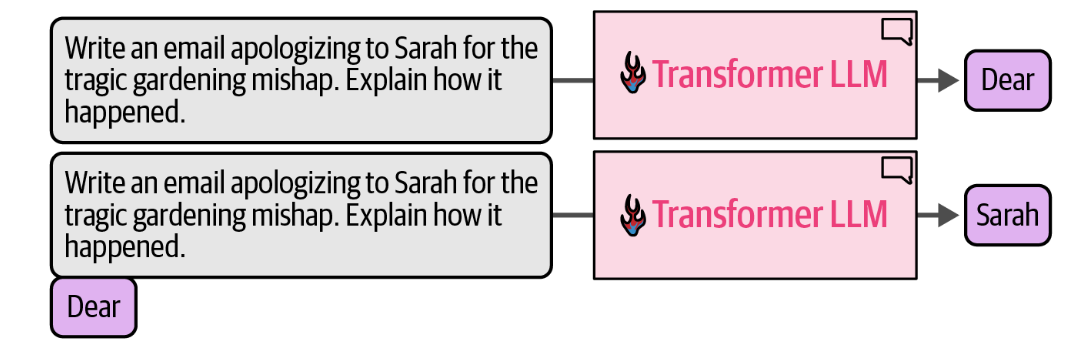

O **cache de KV** (*key-value cache*, controlado pelo parâmetro `use_cache` do método `generate`) resolve esse desperdício: as matrizes de chave e valor de cada token, uma vez calculadas, são armazenadas em memória e reaproveitadas nas iterações seguintes. Assim, a cada passo, o modelo só precisa calcular as matrizes K e V do token recém-gerado, não de toda a sequência.

Na prática, essa é uma das otimizações com maior impacto na experiência do usuário final: mesmo poucos segundos de espera por resposta já são percebidos como uma demora significativa, e é por isso que as APIs de LLMs em produção (Gemini, ChatGPT, Claude, etc.) fazem *streaming* dos tokens gerados, exibindo-os um a um assim que ficam prontos, em vez de esperar a geração completa terminar.

Nas duas células de comparação de desempenho a seguir, geramos o mesmo texto (100 novos tokens) primeiro **com** `use_cache=True` e depois **sem** cache (`use_cache=False`), medindo o tempo de execução com o comando mágico `%%timeit` do Jupyter. No livro, em uma GPU T4 do Colab, a diferença observada foi de aproximadamente 4,5 segundos (com cache) contra 21,8 segundos (sem cache), uma diferença superior a 4 vezes. Ao rodar em seu próprio ambiente (Colab ou EC2), espere ver a mesma tendência qualitativa (com cache sempre mais rápido), mas os valores absolutos de tempo dependerão do hardware disponível; em CPU, sem GPU, ambos os tempos tendem a ser bem mais altos, e a diferença relativa pode variar.


In [ ]:
prompt = "Write a very long email apologizing to Sarah for the tragic gardening mishap. Explain how it happened."

# Tokenize the input prompt
input_ids = tokenizer(prompt, return_tensors="pt").input_ids
input_ids = input_ids.to("cuda")

In [ ]:
%%timeit -n 1
# Generate the text
generation_output = model.generate(
  input_ids=input_ids,
  max_new_tokens=100,
  use_cache=True
)

7.45 s ± 2.82 s per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
%%timeit -n 1
# Generate the text
generation_output = model.generate(
  input_ids=input_ids,
  max_new_tokens=100,
  use_cache=False
)

33.1 s ± 923 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


# Resumo do capítulo

Sintetizando os conceitos centrais trabalhados neste notebook:

- Um Transformer LLM gera **um token por vez**; o token gerado é anexado ao prompt, e a sequência atualizada é reprocessada para gerar o próximo token.
- O modelo é composto por três partes principais: **tokenizador**, uma **pilha de blocos Transformer** e uma **cabeça de modelagem de linguagem (LM head)**.
- O tokenizador mantém o vocabulário do modelo; cada token do vocabulário tem um vetor de embedding associado. Quebrar o texto em tokens e buscar seus embeddings é a primeira etapa do processo de geração.
- Ao final do processamento, a LM head calcula a probabilidade de cada token do vocabulário ser o próximo. A **estratégia de decodificação** (gulosa ou por amostragem) define qual token é efetivamente escolhido.
- Uma das grandes vantagens do Transformer é processar tokens **em paralelo**: cada token de entrada tem seu próprio fluxo de processamento. O número de fluxos possíveis é o **tamanho de contexto** do modelo.
- Como a geração ocorre em loop, é vantajoso fazer **cache** dos resultados intermediários (chaves e valores) de cada etapa, para não repetir cálculos desnecessários.
- A maior parte do processamento ocorre dentro dos **blocos Transformer**, cada um formado por uma **camada de atenção** e uma **rede feedforward**.
- A atenção ocorre em duas etapas: (1) pontuar a relevância de cada posição anterior, e (2) combinar a informação dessas posições com base nessas pontuações. Isso é feito em paralelo em várias **cabeças de atenção**.
- Técnicas como **grouped-query attention** e **Flash Attention** aceleram o cálculo de atenção sem alterar os conceitos fundamentais; **RoPE** é o esquema de embeddings posicionais mais usado nos modelos recentes.

## Referências

ALAMMAR, J.; GROOTENDORST, M. **Hands-On Large Language Models: Language Understanding and Generation**. Sebastopol: O'Reilly Media, 2024. Capítulo 3, "Looking Inside Large Language Models".

VASWANI, A. et al. Attention Is All You Need. In: **Advances in Neural Information Processing Systems (NeurIPS)**, 2017. Disponível em: https://arxiv.org/abs/1706.03762

ABDIN, M. et al. Phi-3 Technical Report: A Highly Capable Language Model Locally on Your Phone. Microsoft Research, 2024. Disponível em: https://arxiv.org/abs/2404.14219

Documentação da biblioteca `transformers` (Hugging Face): https://huggingface.co/docs/transformers

Repositório oficial do livro (código-fonte original deste notebook): https://github.com/HandsOnLLM/Hands-On-Large-Language-Models